In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy import linalg
import networkx as nx # 用于生成复杂的异质拓扑
from scipy.stats import ortho_group
from scipy import stats

In [2]:
def init_matrix_with_controlled_spectrum(N, distribution='uniform', bounds=(0.1, 1.0), symmetric=True):
    """
    初始化权重矩阵 W，并强制其精度矩阵 A = WW^T 具有特定的谱分布和增强的非对角相关性。

    Args:
        N (int): 维度。
        distribution (str): 谱分布类型 ('uniform', 'power_law', 'bimodal')。
        bounds (tuple): 特征值范围 (min, max)。
        symmetric (bool): True=对称W, False=非对称W (Dale兼容)。
        align_mean_mode (bool): 
            - True (关键修改): 强制第一个特征向量指向 [1,1...1]。这会将 lambda[0] 的能量
              广播到整个矩阵的非对角元，使 A_ij 的量级不再趋于 0。
            - False: 纯随机旋转，A_ij 通常为 O(1/sqrt(N))，远小于 A_ii。

    Returns:
        W (ndarray): 权重矩阵。
        A (ndarray): 精度矩阵。
    """
    # --- 1. 生成 A 的特征向量基 Q (Output Basis) ---

    # 原始逻辑：纯随机基 (导致 A 接近对角阵)
    if N < 1000:
        Q = ortho_group.rvs(N)
    else:
        H = np.random.randn(N, N)
        Q, _ = linalg.qr(H)

    # --- 2. 定义 A 的目标谱 (Eigenvalues) ---
    if distribution == 'orthogonal':
        lambdas = np.ones(N) # A = I
    
    elif distribution == 'uniform':
        low, high = bounds
        lambdas = np.random.uniform(low, high, N)
        
    elif distribution == 'power_law':
        # 幂律分布 (Sloppy Model 常用)
        alpha = 1.0
        x = np.random.uniform(0, 1, N)
        lambdas = (1 - x) ** (-1/alpha)
        # 映射到 bounds
        l_min, l_max = lambdas.min(), lambdas.max()
        lambdas = bounds[0] + (lambdas - l_min) * (bounds[1] - bounds[0]) / (l_max - l_min)
        
    elif distribution == 'bimodal':
        # 双峰分布：模拟 E-I 分离的强相互作用
        # 一半很强(Stiff)，一半很弱(Sloppy)
        mid = N // 2
        lambdas = np.zeros(N)
        lambdas[:mid] = np.random.uniform(bounds[0], bounds[0]*10, mid) # Sloppy
        lambdas[mid:] = np.random.uniform(bounds[1]/10, bounds[1], N-mid) # Stiff
        
    else:
        raise ValueError("Unknown distribution")


    # --- 3. 重构 W (Reconstruction) ---
    # A = Q * diag(lambda) * Q.T
    
    sqrt_lam = np.sqrt(lambdas)
    
    if symmetric:
        # W 是对称平方根
        W = Q @ np.diag(sqrt_lam) @ Q.T
    else:
        # W 是混合符号 (Mixed Signs)
        # 使用独立的随机基 V 作为输入空间
        if N < 1000:
            V = ortho_group.rvs(N)
        else:
            H_v = np.random.randn(N, N)
            V, _ = linalg.qr(H_v)
            
        W = Q @ np.diag(sqrt_lam) @ V.T
    
    return W

In [3]:
class RobustHeterogeneousNetwork:
    def __init__(self, N, topology='scale_free', avg_degree=6, 
                 alpha=0.05, C=100.0, 
                 lambda_smooth=0.01, drop_prob=0.1):
        """
        Args:
            N (int): 神经元数量
            topology (str): 'small_world', 'scale_free', 'random'
            avg_degree (int): 平均连接度
            alpha (float): 熵正则化系数 (防止秩崩溃)
            C (float): 总能量约束 (Trace constraint)
            lambda_smooth (float): 拉普拉斯平滑强度 (强制空间连续性，降低IPR)
            drop_prob (float): DropConnect 概率 (引入噪声，强制鲁棒性)
        """
        self.N = N
        self.alpha = alpha
        self.C = C
        self.lambda_smooth = lambda_smooth
        self.drop_prob = drop_prob
        
        # 1. 构建异质拓扑结构 (Adjacency Mask)
        self.mask = self._generate_topology(topology, avg_degree)
        
        # 2. 预计算结构拉普拉斯矩阵 (Structural Laplacian)
        # 用于正则化：L = D - Adj
        # 这是基于物理连接的，不是基于功能权重的
        degree_matrix = np.diag(np.sum(self.mask, axis=1))
        self.L_struct = degree_matrix - self.mask
        
        # 3. 初始化权重 (Random Orthogonal-ish)
        # 使用较小的随机值，打破对称性
        w=init_matrix_with_controlled_spectrum(N, distribution='uniform', bounds=(0.9, 1))
        # w=np.random.randn(N, N) * 0.1
        w*=self.mask
        self.W = w
        
        current_energy = np.sum(w** 2) + 1e-12
        scale = np.sqrt(self.C / current_energy)
        w*= scale
        self.W_init=w
        
        A_init=w@ w.T + np.eye(self.N)*1e-6
        self.A_init=A_init
        self.A=A_init

    def _generate_topology(self, kind, avg_k):
        if kind == 'small_world':
            G = nx.watts_strogatz_graph(self.N, k=avg_k, p=0.2)
        elif kind == 'scale_free':
            m = max(1, avg_k // 2)
            G = nx.barabasi_albert_graph(self.N, m)
        else: # Random
            p = avg_k / self.N
            G = nx.erdos_renyi_graph(self.N, p)
            
        adj = nx.to_numpy_array(G)
        np.fill_diagonal(adj, 1.0) # Self-loops allowed
        return adj

    def normalize_W(self):
        """严格执行能量约束: Tr(WW^T) = C"""
        current_energy = np.sum(self.W ** 2) + 1e-12
        scale = np.sqrt(self.C / current_energy)
        self.W *= scale

    def get_effective_W(self, training=False):
        """
        获取当前权重。
        如果 training=True，应用 DropConnect (随机屏蔽连接)。
        """
        W_masked = self.W * self.mask
        
        if training and self.drop_prob > 0: #drop connection 使 W最终不对称
            # 生成二值 Drop 掩码 (1 = 保留, 0 = 丢弃)
            # 概率 (1-p) 保留
            drop_mask = (np.random.rand(*self.W.shape) > self.drop_prob).astype(float)
            
            # 缩放权重以保持期望值不变 (Inverted Dropout)
            # W_eff = W * mask / (1-p)
            scale = 1.0 / (1.0 - self.drop_prob)
            return W_masked * drop_mask * scale
        
        return W_masked

    def update_hebbian(self, v, lr):
        """
        v: 输入信号在神经元上的投影 (Input projection)
        """
        # 1. 获取“带噪声”的权重视图 (DropConnect)
        # 这迫使网络不依赖特定的单一连接
        W_eff = self.get_effective_W(training=True)
        
        # 2. 计算当前精度矩阵 A (基于带噪声的权重)
        A = W_eff @ W_eff.T + np.eye(self.N)*1e-6
        self.A=A
        
        # 计算 A 的逆 (协方差)
        try:
            A_inv = np.linalg.inv(A)
        except np.linalg.LinAlgError:
            A_inv = np.linalg.pinv(A)

        # --- 梯度项计算 ---

        # A. Fisher Information Gradient (驱动力)
        # Term: v * v^T * W
        # 这一项让主要特征向量对齐信号方向
        grad_fisher = np.outer(v, v) @ W_eff
        
        # B. Entropy Regularization (最大熵/白化)
        # Term: alpha * A^-1 * W
        # 这一项防止所有特征值坍缩到同一个方向，保持秩
        grad_entropy = self.alpha * (A_inv @ W_eff)
        
        # C. Laplacian Regularization (空间平滑约束) - NEW
        # Loss = lambda * Tr(W^T L W) -> 邻居节点的权重应相似
        # Gradient = 2 * lambda * L @ W
        # 这强迫“软模式”在网络拓扑上是平滑变化的，直接对抗局域化(Localization)
        grad_smooth = self.lambda_smooth * (self.L_struct @ self.W)

        # D. Trace Constraint (能量约束拉格朗日乘子)
        # 动态计算 beta 以抵消增长
        v_proj = v.T @ A @ v
        # 粗略估计 beta，依靠后续 normalize_W 做精确修正
        beta = (v_proj + self.alpha * self.N) / self.C
        grad_trace = beta * W_eff


        
        
        # --- 组合梯度 ---
        # 注意：grad_smooth 是减去项（惩罚），grad_trace 也是减去项
        total_grad = 2 * (grad_fisher + grad_entropy - grad_trace) - grad_smooth
        
        # --- 更新 ---
        self.W += lr * total_grad
        
        # 强制拓扑约束 (Re-masking)
        self.W *= self.mask
        
        # 严格归一化 (防止数值漂移)
        self.normalize_W()

In [4]:
def get_gradients(N, mode='local'):
    x = np.linspace(0, 1, N)
    if mode == 'local':
        # 1. Localized: Only neurons near center care about s
        # return np.exp(-(x - 0.5)**2 / (2 * 0.05**2)).reshape(-1, 1)
        return np.sin(x * 0.5) * np.exp(-0.5 * (x / 15.0)**2) # High freq sensitivity
    
    elif mode == 'global_shift':
        # 2. Global: A wave-like gradient across all neurons
        return np.sin(2 * np.pi * x).reshape(-1, 1)
        # return np.exp(-0.5 * (x / 6.0)**2) # Low freq sensitivity
    
    elif mode == 'mean_field':
        # 3. Mean Field: All neurons care equally

        a=np.ones((N, 1))
        # a[:N//2]=-1
        return a#np.random.choice([1, -1], size=N)#np.ones((N, 1))
        # return np.linspace(0.9,1.0,N)
    elif mode == '线性全局漂移':   
        return (x - 0.5).reshape(-1, 1)
    elif mode == '低频余弦':
        return np.cos(np.pi * x).reshape(-1, 1)
    elif mode == 'Gaussian-shaped-global':
        return np.exp(-0.5 * ((x - 0.5) / 0.25)**2).reshape(-1, 1)

In [5]:
def calculate_xi_field_theory(A, N):
    """
    Corrected Ginzburg-Landau correlation length calculation.
    xi = sqrt(kappa / m^2)
    """
    # 1. Get eigenvalues and eigenvectors
    # We use eigh because A is symmetric
    vals, vecs = np.linalg.eigh(A)
    
    # Sort them just in case (eigh usually returns sorted)
    idx = np.argsort(vals)
    vals = vals[idx]
    vecs = vecs[:, idx]
    
    # 2. Identify the 'Mass' (Soft Mode eigenvalue)
    # This is the precision gap. If A is singular, m2 -> 0
    m2 = vals[0]
    
    # 4. Compute Correlation Length
    # Use a small epsilon to avoid division by zero at the critical point
    epsilon = 1e-12
    xi = np.sqrt(1 / (m2 + epsilon))
    
    # 5. Finite Size Clipping
    # Physical xi cannot meaningfully exceed the system size N
    return min(xi, N)

In [6]:
def analyze_spectral_criticality(A_matrix, tol=1e-9):
    """
    Quantifies the criticality of a neural system using spectral methods.
    
    Args:
        A_matrix (np.ndarray): The NxN symmetric precision matrix (inverse covariance).
                               Represents the energy landscape curvature.
        tol (float): Threshold to treat eigenvalues as effectively zero.
        
    Returns:
        dict: Dictionary containing:
            - 'spectral_gap': The smallest non-zero eigenvalue (lambda_min).
            - 'correlation_length': Effective spatial range (xi).
            - 'ipr': Inverse Participation Ratio of the softest mode (Y).
            - 'is_critical': Boolean flag if system is near criticality.
    """
    # 1. Eigen-decomposition (using eigh for symmetric/Hermitian matrices)
    # eigenvalues are returned in ascending order
    evals, evecs = linalg.eigh(A_matrix)
    
    # 2. Identify the "Softest Mode" (Mass Term)
    # In a precision matrix, the smallest eigenvalue corresponds to the 
    # flattest direction in the energy landscape (highest variance).
    lambda_min = evals[0]
    
    # Handle numerical instability if lambda_min is practically zero (Goldstone mode)
    if lambda_min < tol:
        xi = np.inf
    else:
        # Formula: xi ~ 1 / sqrt(lambda_min)
        xi = 1.0 / np.sqrt(lambda_min)
        
    # 3. Compute Inverse Participation Ratio (IPR)
    # IPR quantifies the spatial extent of the eigenmode.
    # Y = sum(u_i^4) for normalized u.
    # If Y ~ 1/N -> Delocalized (Critical/Collective state).
    # If Y ~ 1   -> Localized (Single neuron state).
    
    u_soft = evecs[:, 0]  # Eigenvector corresponding to lambda_min
    
    # Ensure normalization (eigh usually returns normalized vectors, but good to be safe)
    u_soft = u_soft / np.linalg.norm(u_soft)
    
    ipr = np.sum(u_soft ** 4)
    
    return {
        "spectral_gap": lambda_min,
        "correlation_length": xi,
        "ipr": ipr,
        "regime": "Delocalized (Critical)" if ipr < (5.0 / len(A_matrix)) else "Localized",
        "soft_mode_vector": u_soft
    }

In [7]:
result_dir='result/'
modes=['local','global_shift','mean_field','线性全局漂移','低频余弦','Gaussian-shaped-global']
N_arr=np.array([100,200,300,400,500,600])
C = 2e2
H_weight=1e-3
topo='random'

Spectral Gap (Mass^2): 0.4070
Correlation Length:      1.5676
IPR (Localization):      0.0644
Regime:                  Localized
Spectral Gap (Mass^2): 0.0003
Correlation Length:      59.5733
IPR (Localization):      0.0411
Regime:                  Localized
Spectral Gap (Mass^2): 0.0000
Correlation Length:      444.3728
IPR (Localization):      0.0231
Regime:                  Localized
Spectral Gap (Mass^2): 0.0000
Correlation Length:      953.5063
IPR (Localization):      0.0111
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      506.4738
IPR (Localization):      0.0111
Regime:                  Localized
Spectral Gap (Mass^2): 0.0000
Correlation Length:      999.3106
IPR (Localization):      0.0065
Regime:                  Delocalized (Critical)


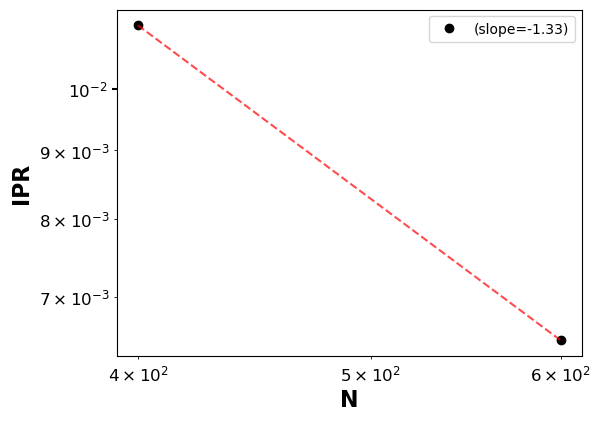

Spectral Gap (Mass^2): 0.2921
Correlation Length:      1.8502
IPR (Localization):      0.0942
Regime:                  Localized
Spectral Gap (Mass^2): 0.0020
Correlation Length:      22.6124
IPR (Localization):      0.0814
Regime:                  Localized
Spectral Gap (Mass^2): 0.0000
Correlation Length:      537.2247
IPR (Localization):      0.0182
Regime:                  Localized
Spectral Gap (Mass^2): 0.0000
Correlation Length:      273.5514
IPR (Localization):      0.0133
Regime:                  Localized
Spectral Gap (Mass^2): 0.0000
Correlation Length:      552.0774
IPR (Localization):      0.0094
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      776.4046
IPR (Localization):      0.0082
Regime:                  Delocalized (Critical)


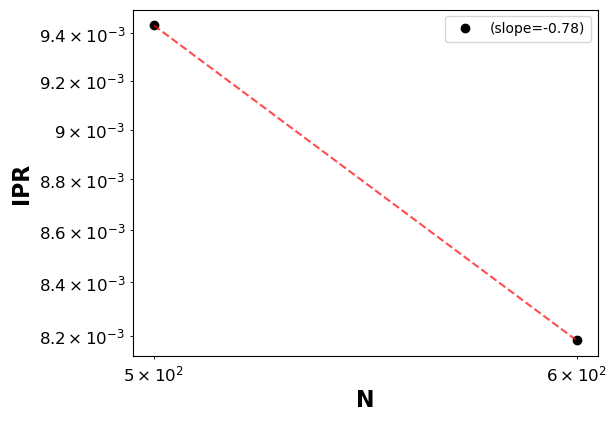

Spectral Gap (Mass^2): 0.4386
Correlation Length:      1.5100
IPR (Localization):      0.0740
Regime:                  Localized
Spectral Gap (Mass^2): 0.0006
Correlation Length:      39.9510
IPR (Localization):      0.0503
Regime:                  Localized
Spectral Gap (Mass^2): 0.0002
Correlation Length:      74.1195
IPR (Localization):      0.0162
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      985.3400
IPR (Localization):      0.0145
Regime:                  Localized
Spectral Gap (Mass^2): 0.0000
Correlation Length:      454.8696
IPR (Localization):      0.0077
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      496.3330
IPR (Localization):      0.0103
Regime:                  Localized


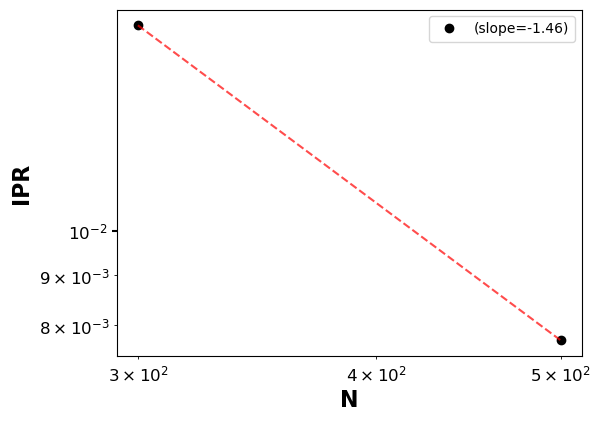

Spectral Gap (Mass^2): 0.5232
Correlation Length:      1.3825
IPR (Localization):      0.0823
Regime:                  Localized
Spectral Gap (Mass^2): 0.0023
Correlation Length:      20.6289
IPR (Localization):      0.0465
Regime:                  Localized
Spectral Gap (Mass^2): 0.0001
Correlation Length:      96.0726
IPR (Localization):      0.0231
Regime:                  Localized
Spectral Gap (Mass^2): 0.0000
Correlation Length:      329.4923
IPR (Localization):      0.0105
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      992.6532
IPR (Localization):      0.0090
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      483.3775
IPR (Localization):      0.0059
Regime:                  Delocalized (Critical)


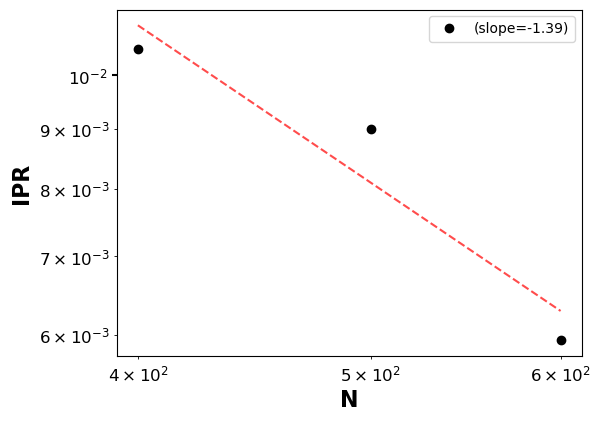

Spectral Gap (Mass^2): 0.5720
Correlation Length:      1.3222
IPR (Localization):      0.1201
Regime:                  Localized
Spectral Gap (Mass^2): 0.0008
Correlation Length:      34.4104
IPR (Localization):      0.0737
Regime:                  Localized
Spectral Gap (Mass^2): 0.0000
Correlation Length:      903.9077
IPR (Localization):      0.0166
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      813.5407
IPR (Localization):      0.0141
Regime:                  Localized
Spectral Gap (Mass^2): 0.0000
Correlation Length:      559.5480
IPR (Localization):      0.0090
Regime:                  Delocalized (Critical)
Spectral Gap (Mass^2): 0.0000
Correlation Length:      901.3166
IPR (Localization):      0.0065
Regime:                  Delocalized (Critical)


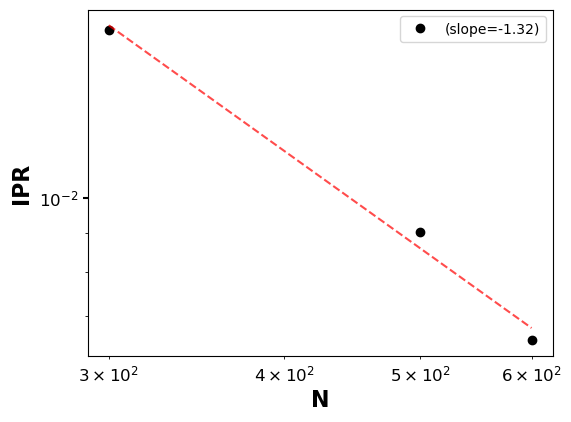

In [8]:
ipr_arrs = []
N_arr_ipr_all = []
m = modes[3]
for ei in range(5):
    # A_arr=[]
    # W_arr=[]
    # Ai_arr=[]
    # Wi_arr=[]
    ipr_n=[]
    N_arr_ipr = []
    for N in N_arr:
        f_prime = get_gradients(N, mode=m)
        model=RobustHeterogeneousNetwork(N, topology=topo, avg_degree=N//10, alpha=H_weight, C=C, 
                     lambda_smooth=0.01, drop_prob=0.1)
        # h_fisher, h_xi,h_xi_fft= [], [],[]
    
        for _ in range(300):
            W = model.get_effective_W()
            A =  W @ W.T + np.eye(N)*1e-6
            fi=f_prime.T @ A @ f_prime
            # h_fisher.append(fi.item())
            
            # h_xi.append(calculate_xi_field_theory(A, N))
            # # h_xi_fft.append(calculate_xi_fourier_method(A, N))
                    
            model.update_hebbian(f_prime, lr=0.001)
    
        # A_arr.append(A)
        # W_arr.append(model.W)
        # Ai_arr.append(model.A_init)
        # Wi_arr.append(model.W_init)
        # np.save(result_dir+'A'+str(N)+'_mat.npy',A)
    
        results = analyze_spectral_criticality(A)
        
        print(f"Spectral Gap (Mass^2): {results['spectral_gap']:.4f}")
        print(f"Correlation Length:      {results['correlation_length']:.4f}")
        print(f"IPR (Localization):      {results['ipr']:.4f}")
        print(f"Regime:                  {results['regime']}")
        # ipr_n.append(results['ipr']) #改动了这
        if results['regime'] == 'Delocalized (Critical)':
            ipr_n.append(results['ipr'])
            N_arr_ipr.append(N)

    ipr_arr=np.array(ipr_n)
    slope, intercept, r, p, std = linregress(np.log10(N_arr_ipr), np.log10(ipr_arr))
    
    
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['xtick.major.width'] = 1.5
    plt.rcParams['ytick.major.width'] = 1.5
    
    fig,ax=plt.subplots(figsize=(6, 4.5))
    ax.loglog(N_arr_ipr, ipr_arr, 'o', color='black', label=f'(slope={slope:.2f})')
    ax.loglog(N_arr_ipr, 10**intercept * N_arr_ipr**slope, '--', alpha=0.7,color='red')
    
    plt.xlabel('N',fontsize=16,fontweight='bold')
    plt.ylabel('IPR',fontsize=16,fontweight='bold')
    
    
    plt.legend()
    # plt.savefig(result_dir+'IPR.png',bbox_inches='tight',dpi=300)
    plt.show()
    # if slope>-1.15 and slope<-0.85:
    #     ipr_arrs.append(ipr_arr)
    
    ipr_arrs.append(np.array(ipr_n))
    N_arr_ipr_all.append(np.array(N_arr_ipr))
    
    # np.save(result_dir+'IPR.npy',ipr_arr)



In [9]:
ipr_arrs

[array([0.01114664, 0.00649586]),
 array([0.00943453, 0.00818242]),
 array([0.01624602, 0.00772347]),
 array([0.01052431, 0.00899314, 0.00593574]),
 array([0.01661218, 0.00902918, 0.00650676])]

In [10]:
from collections import defaultdict

ipr_by_N = defaultdict(list)

for Ns, iprs in zip(N_arr_ipr_all, ipr_arrs):
    for N, ipr in zip(Ns, iprs):
        ipr_by_N[N].append(ipr)

N_valid = []
mean_ipr = []
std_ipr = []

for N in N_arr:

    if N in ipr_by_N:

        N_valid.append(N)
        mean_ipr.append(np.mean(ipr_by_N[N]))
        std_ipr.append(np.std(ipr_by_N[N]))

N_valid = np.array(N_valid)
mean_ipr = np.array(mean_ipr)
std_ipr = np.array(std_ipr)

slope, intercept, r, p, std = linregress(
    np.log10(N_valid),
    np.log10(mean_ipr)
)

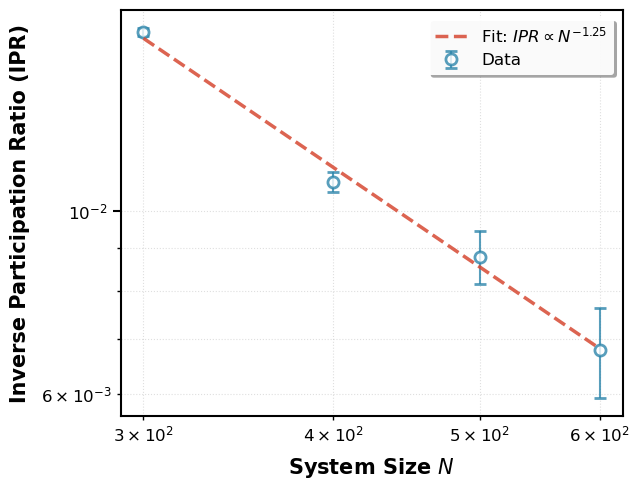

In [11]:
lower_err = mean_ipr - (mean_ipr - std_ipr)  # or however you want to define it
upper_err = (mean_ipr + std_ipr) - mean_ipr

# Set style parametersedgecolor
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.edgecolor'] = 'none'

fig,ax=plt.subplots(figsize=(6.5, 5))

# Define color palette
colors = {
    'data': '#2E86AB',      # Blue
    'fit': '#D64933',       # Red
    'error': '#2E86AB',     # Same as data
    'fill': '#2E86AB'       # For fill between
}

# Plot with error bars - semi-transparent fill for better visual
ax.errorbar(N_valid, mean_ipr, 
            yerr=[lower_err, upper_err], 
            fmt='o', 
            color=colors['data'],
            markersize=8,
            markerfacecolor='white',
            markeredgewidth=2,
            capsize=4,
            capthick=2,
            elinewidth=1.5,
            ecolor=colors['error'],
            alpha=0.8,
            # label=f'Data (slope={slope:.2f})',
            label='Data',
            zorder=2)

# # Add shaded error region (optional - more visual)
# ax.fill_between(N_arr, 
#                 mean_ipr - std_ipr, 
#                 mean_ipr + std_ipr, 
#                 color=colors['fill'],
#                 alpha=0.15,
#                 zorder=1)

# Fit line with better styling
ax.loglog(N_valid, 10**intercept * N_valid**slope, 
          '--', 
          linewidth=2.5,
          color=colors['fit'],
          alpha=0.85,
          label=f'Fit: $IPR \\propto N^{{{slope:.2f}}}$',
          zorder=3)

# # Add R² value annotation
# r_squared = r**2
# ax.text(0.05, 0.95, 
#         f'$R^2 = {r_squared:.3f}$',
#         transform=ax.transAxes,
#         fontsize=13,
#         fontweight='bold',
#         verticalalignment='center',
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))

# Customize axis labels
plt.xlabel('System Size $N$', fontsize=15, fontweight='bold', labelpad=8)
plt.ylabel('Inverse Participation Ratio (IPR)', fontsize=15, fontweight='bold', labelpad=8)

# Customize legend
legend = plt.legend(frameon=True, 
                   fontsize=12,
                   loc='best',
                   fancybox=True,
                   shadow=True,
                   framealpha=0.95)
legend.get_frame().set_linewidth(0)

# Add grid for better readability
ax.grid(True, which='both', linestyle=':', alpha=0.4, linewidth=0.8)
ax.set_axisbelow(True)

# Tweak tick parameters
ax.tick_params(axis='both', which='major', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', length=3, width=1)

# Adjust layout
plt.tight_layout()

plt.savefig(result_dir+f'IPR_{m}.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()